In [1]:
# === ONE-CELL ASR→METRICS PIPELINE (print only, list-friendly) ===============
# (WAV→16k) → Whisper ASR → jiwer metrics (WER/MER(/WIL/WIP) + detailed) + CER
# ------------------------------------------------------------------------------
# USER PARAMS


INPUT    = [
    "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/big_seminar/Big_seminar_room_SJR-35.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/big_seminar/Big_seminar_room_SJR-30.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/big_seminar/Big_seminar_room_SJR-25.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/big_seminar/Big_seminar_room_SJR-20.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/big_seminar/Big_seminar_room_SJR-15.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/big_seminar/Big_seminar_room_SJR-10.wav"
]


#INPUT    = "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/file1.wav"
REF_TEXT = None
#REF_FILE = '/home/C_Weight/jaewoo_test/00micloaker/dataset/gttext/target_1284.txt'                   # 텍스트 파일 경로를 쓰면 REF_TEXT 대신 사용
REF_FILE = '/home/C_Weight/jaewoo_test/00micloaker/dataset/30min_transcript.txt'                   # 텍스트 파일 경로를 쓰면 REF_TEXT 대신 사용


MODELS   = ["large-v3"]            # ["tiny","base","small","medium","large-v3", ...]
LANG     = "en"
TARGET_SR= 16000

# ------------------------------------------------------------------------------
# IMPORTS & AUTO SETUP
import sys, subprocess, importlib, warnings, os, re, glob
from pathlib import Path
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def ensure(modname, pipname=None):
    try:
        return importlib.import_module(modname)
    except Exception:
        pname = pipname or modname
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pname])
        return importlib.import_module(modname)

# core deps (필요시 자동 설치)
np       = ensure("numpy")
sf       = ensure("soundfile")
librosa  = ensure("librosa")
pd       = ensure("pandas")
contractions = ensure("contractions")
whisper  = ensure("whisper", "openai-whisper")
jiwer_mod= ensure("jiwer")

# jiwer 버전별 임포트 처리
try:
    from jiwer import wer, mer, wil, wip, compute_measures
except Exception:
    # 구버전 호환
    from jiwer import wer, mer, wil, wip
    def compute_measures(ref, hyp):
        return {
            "wer": wer(ref, hyp),
            "mer": mer(ref, hyp),
            "wil": wil(ref, hyp),
            "wip": wip(ref, hyp),
            "substitutions": None,
            "insertions": None,
            "deletions": None,
            "hits": None,
        }

try:
    import torch
except Exception:
    torch = None

def _cuda_available():
    try:
        return torch.cuda.is_available() if torch is not None else False
    except Exception:
        return False

# ------------------------------------------------------------------------------
# HELPERS
import numpy as _np

def normalize_text(text: str) -> str:
    # 공백토큰 제거 → 수축형 복원 → 대문자 → 하이픈 분절 → 영숫자+공백만 → 공백정규화
    text = text.replace('▁', ' ')
    text = contractions.fix(text)
    text = text.upper()
    text = re.sub(r"(\w+)-(\w+)", r"\1 \2", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def read_audio(path: Path, target_sr=None, mono=True):
    y, sr = librosa.load(str(path), sr=target_sr, mono=mono)
    return y, sr

def resample_to_16k(y, orig_sr, target_sr=16000):
    if orig_sr == target_sr:
        return _np.asarray(y, dtype=_np.float32)
    y16 = librosa.resample(y, orig_sr=orig_sr, target_sr=target_sr)
    return _np.asarray(y16, dtype=_np.float32)

def load_ref(ref_text=None, ref_file=None):
    if ref_file:
        return normalize_text(Path(ref_file).read_text(encoding="utf-8"))
    if ref_text is not None:
        return normalize_text(ref_text)
    raise ValueError("REF_TEXT 또는 REF_FILE 중 하나는 반드시 설정하세요.")

# --- CER (Character Error Rate, 공백 무시) ------------------------------------
def cer(ref: str, hyp: str) -> float:
    """
    CER = edit_distance(ref, hyp) / len(ref)
    - 공백은 제거 후 계산 (일반적인 CER 관행)
    """
    r = list(ref.replace(" ", ""))
    h = list(hyp.replace(" ", ""))
    R, H = len(r), len(h)
    if R == 0:
        return 0.0 if H == 0 else 1.0

    d = _np.zeros((R+1, H+1), dtype=_np.int32)
    for i in range(R+1):
        d[i, 0] = i
    for j in range(H+1):
        d[0, j] = j
    for i in range(1, R+1):
        ri = r[i-1]
        for j in range(1, H+1):
            cost = 0 if ri == h[j-1] else 1
            d[i, j] = min(
                d[i-1, j] + 1,      # deletion
                d[i, j-1] + 1,      # insertion
                d[i-1, j-1] + cost  # substitution
            )
    return float(d[R, H]) / float(R)

# ------------------------------------------------------------------------------
# ASR Wrapper (Whisper)
class ASRComputation:
    def __init__(self, asr_type: str = 'large-v3', fs: int = 16000, lang: str = 'en'):
        self.asr_type = asr_type
        self.fs = fs
        self.lang = lang
        self.model = whisper.load_model(self.asr_type)

    def transcribe(self, audio_np):
        kwargs = {}
        if not _cuda_available():
            kwargs["fp16"] = False
        out = self.model.transcribe(audio_np, language=self.lang, verbose=False, **kwargs)
        return out.get("text", "")

# ------------------------------------------------------------------------------
# RUN
ref_norm = load_ref(REF_TEXT, REF_FILE)

def expand_inputs(inp):
    """
    inp: str/Path (파일·디렉터리·글롭), 또는 이들의 (중첩) 리스트/튜플/셋
    -> 존재하는 .wav 파일 리스트로 확장
    """
    def _expand_one(x):
        # 컨테이너(중첩) 지원
        if isinstance(x, (list, tuple, set)):
            for y in x:
                yield from _expand_one(y)
            return

        s = str(x)
        p = Path(s)

        # 글롭 패턴
        if any(ch in s for ch in "*?[]"):
            for g in glob.glob(s):
                yield Path(g)
            return

        # 디렉터리면 *.wav
        if p.is_dir():
            for w in sorted(p.glob("*.wav")):
                yield w
            return

        # 일반 파일
        yield p

    paths = [pp.resolve() for pp in _expand_one(inp)]
    paths = [pp for pp in paths if pp.exists()]
    return paths

wav_list = expand_inputs(INPUT)
if not wav_list:
    raise FileNotFoundError("입력 WAV를 찾을 수 없습니다. INPUT 값을 확인하세요.")

print("\n========== ASR → jiwer metrics ==========")
print(f"REF (normalized): {ref_norm}\n")

for wav_path in wav_list:
    y, sr = read_audio(wav_path, target_sr=None)
    y16 = resample_to_16k(y, sr, TARGET_SR)

    print(f"--- File: {wav_path.name} ---")
    for m in MODELS:
        asr = ASRComputation(m, fs=TARGET_SR, lang=LANG)
        hyp = asr.transcribe(y16)
        hyp_norm = normalize_text(hyp)

        # 지표 계산
        WER = wer(ref_norm, hyp_norm) * 100.0
        MER = mer(ref_norm, hyp_norm) * 100.0
        WIL = wil(ref_norm, hyp_norm) * 100.0
        WIP = wip(ref_norm, hyp_norm) * 100.0
        CER = cer(ref_norm, hyp_norm) * 100.0
        measures = compute_measures(ref_norm, hyp_norm)

        # 출력
        print(f"[{m}]")
        print(f"  HYP(raw):  {hyp}")
        print(f"  HYP(norm): {hyp_norm}")
        print(f"  WER : {WER:.2f}%")
        print(f"  MER : {MER:.2f}%")
        print(f"  WIL : {WIL:.2f}%")
        print(f"  WIP : {WIP:.2f}%")
        print(f"  CER : {CER:.2f}%")
        print("  --- Detailed measures ---")
        for k, v in measures.items():
            if isinstance(v, float):
                print(f"    {k:12s}: {v*100:.2f}%")
            else:
                print(f"    {k:12s}: {v}")
    print()

print("\nDone.")



========== ASR → jiwer metrics ==========
REF (normalized): HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIECES TO BE LADLED OUT IN THICK PEPPERED FLOUR FATTENED SAUCE STUFF IT INTO YOU HIS BELLY COUNSELLED HIM AFTER EARLY NIGHTFALL THE YELLOW LAMPS WOULD LIGHT UP HERE AND THERE THE SQUALID QUARTER OF THE BROTHELS HELLO BERTIE ANY GOOD IN YOUR MIND NUMBER TEN FRESH NELLY IS WAITING ON YOU GOOD NIGHT HUSBAND THE MUSIC CAME NEARER AND HE RECALLED THE WORDS THE WORDS OF SHELLEYS FRAGMENT UPON THE MOON WANDERING COMPANIONLESS PALE FOR WEARINESS THE DULL LIGHT FELL MORE FAINTLY UPON THE PAGE WHEREON ANOTHER EQUATION BEGAN TO UNFOLD ITSELF SLOWLY AND TO SPREAD ABROAD ITS WIDENING TAIL A COLD LUCID INDIFFERENCE REIGNED IN HIS SOUL THE CHAOS IN WHICH HIS ARDOUR EXTINGUISHED ITSELF WAS A COLD INDIFFERENT KNOWLEDGE OF HIMSELF AT MOST BY AN ALMS GIVEN TO A BEGGAR WHOSE BLESSING HE FLED FROM HE MIGHT HOPE WEARILY TO WIN FOR HIMSELF SOME MEASURE O

  0%|          | 0/180003 [00:00<?, ?frames/s]


KeyboardInterrupt: 

In [1]:
# === ONE-CELL: Whisper → transcript only =====================================
# 입력 WAV 경로들에서 인식된 문장(text)만 출력
# -----------------------------------------------------------------------------

# === USER PARAMS ===
INPUT = [
    "/home/C_Weight/jaewoo_test/00micloaker/1284_15s.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/nojammed_15s.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/jammed_15s.wav"
]
MODEL = "large-v3"   # e.g., "base", "small", "medium", "large-v3"
LANG  = "en"         # 영어 고정. 자동 감지 원하면 None

# === IMPORTS (필요시 자동 설치) ===
import sys, subprocess, importlib, os

def ensure(modname, pipname=None):
    try:
        return importlib.import_module(modname)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pipname or modname])
        return importlib.import_module(modname)

whisper = ensure("whisper", "openai-whisper")
try:
    import torch
    CUDA_OK = torch.cuda.is_available()
except Exception:
    CUDA_OK = False

# === MODEL ===
model = whisper.load_model(MODEL)

# === TRANSCRIBE ===
if isinstance(INPUT, str):
    INPUT = [INPUT]

for wav_path in INPUT:
    kwargs = {"verbose": False}
    if LANG:          # LANG=None 이면 자동 언어 감지
        kwargs["language"] = LANG
    if not CUDA_OK:   # CPU에서 fp16 비활성화
        kwargs["fp16"] = False

    result = model.transcribe(wav_path, **kwargs)
    text   = (result.get("text") or "").strip()

    print(f"--- {os.path.basename(wav_path)} ---")
    print(text)
    print()  # 빈 줄


100%|██████████| 1510/1510 [00:01<00:00, 1188.35frames/s]


--- 1284_15s.wav ---
he wore blue silk stockings blue knee-pants with gold buckles a blue ruffled waist and a jacket of bright blue braided with gold his hat had a peaked crown at a flat brim and around the brim was a row of tiny golden bells that tinkled when he



100%|██████████| 1510/1510 [00:01<00:00, 1157.71frames/s]


--- nojammed_15s.wav ---
silk stockings blue knee-pants with gold buckles a blue ruffled waist and a jacket of bright blue braided with gold his hat had a peaked crown at a flat brim and around the brim was a row of tiny golden bells that tinkled when he moved



100%|██████████| 1510/1510 [00:00<00:00, 13908.68frames/s]

--- jammed_15s.wav ---
Thank you.



## Inference CODE

In [4]:
# === ONE-CELL ASR→METRICS (WER & CER only) ===================================
# (WAV→16k) → Whisper ASR → normalize → WER/CER
# ------------------------------------------------------------------------------

# === USER PARAMS ===
INPUT    = [
    "/home/C_Weight/jaewoo_test/00micloaker/1284_15s.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/nojammed_15s.wav",
    "/home/C_Weight/jaewoo_test/00micloaker/jammed_15s.wav"
    ]


#INPUT    = "/home/C_Weight/jaewoo_test/00micloaker/diff_room_record/file1.wav"
REF_TEXT = None
REF_FILE = '/home/C_Weight/jaewoo_test/00micloaker/1284_15s.txt'                  # 텍스트 파일 경로를 쓰면 REF_TEXT 대신 사용
#REF_FILE = '/home/C_Weight/jaewoo_test/00micloaker/dataset/30min_transcript.txt'                   # 텍스트 파일 경로를 쓰면 REF_TEXT 대신 사용

MODEL    = "large-v3"
LANG     = "en"
TARGET_SR= 16000

# === IMPORTS (필요시 자동 설치) ===
import sys, subprocess, importlib, warnings, os, re, numpy as np
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def ensure(modname, pipname=None):
    try:
        return importlib.import_module(modname)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pipname or modname])
        return importlib.import_module(modname)

librosa       = ensure("librosa")
sf            = ensure("soundfile")
contractions  = ensure("contractions")
whisper       = ensure("whisper", "openai-whisper")
from jiwer import wer
try:
    import torch
    CUDA_OK = torch.cuda.is_available()
except Exception:
    CUDA_OK = False

# === REF 읽기 & 정규화 ===
if REF_FILE:
    ref_raw = open(REF_FILE, "r", encoding="utf-8").read()
elif REF_TEXT is not None:
    ref_raw = REF_TEXT
else:
    raise ValueError("REF_TEXT 또는 REF_FILE 중 하나는 반드시 설정하세요.")

# ref/hyp 텍스트 정규화 규칙(재사용 안 하므로 여기서 바로 기술)
def _normalize(s: str) -> str:
    s = s.replace("▁", " ")
    s = contractions.fix(s)
    s = s.upper()
    s = re.sub(r"(\w+)-(\w+)", r"\1 \2", s)     # HYPHEN → space 분절
    s = re.sub(r"[^\w\s]", "", s)               # 영숫자/공백만
    s = re.sub(r"\s+", " ", s).strip()
    return s

ref_norm = _normalize(ref_raw)

# CER(공백 제거 후 문자기반 edit distance)
def _cer(a: str, b: str) -> float:
    ra = list(a.replace(" ", ""))
    rb = list(b.replace(" ", ""))
    R, H = len(ra), len(rb)
    if R == 0:
        return 0.0 if H == 0 else 1.0
    d = np.zeros((R+1, H+1), dtype=np.int32)
    d[:,0] = np.arange(R+1)
    d[0,:] = np.arange(H+1)
    for i in range(1, R+1):
        ai = ra[i-1]
        for j in range(1, H+1):
            cost = 0 if ai == rb[j-1] else 1
            d[i,j] = min(d[i-1,j]+1, d[i,j-1]+1, d[i-1,j-1]+cost)
    return d[R,H] / float(R)

# === 모델 로드 ===
model = whisper.load_model(MODEL)

#print("\n========== ASR → WER & CER ==========")
#print(f"REF (norm): {ref_norm}\n")

# === 파일 루프 (입력은 WAV 경로 리스트로 가정) ===
for wav_path in INPUT:
    # 1) 로드 → 16k 리샘플
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR).astype("float32")

    # 2) ASR
    transcribe_kwargs = {"language": LANG, "verbose": False}
    if not CUDA_OK:
        transcribe_kwargs["fp16"] = False
    out = model.transcribe(y, **transcribe_kwargs)
    hyp_raw  = out.get("text", "")
    hyp_norm = _normalize(hyp_raw)

    # 3) 지표
    WER = wer(ref_norm, hyp_norm) * 100.0
    CER = _cer(ref_norm, hyp_norm) * 100.0

    # 4) 출력 (WER & CER만)
    print(f"--- File: {os.path.basename(wav_path)} ---")
    #print(f"  HYP(raw):  {hyp_raw}")
    #print(f"  HYP(norm): {hyp_norm}")
    print(f"  WER : {WER:.2f}%")
    print(f"  CER : {CER:.2f}%\n") 

print("Done.")



100%|██████████| 1510/1510 [00:00<00:00, 1602.07frames/s]


--- File: 1284_15s.wav ---
  WER : 2.04%
  CER : 1.03%



100%|██████████| 1510/1510 [00:00<00:00, 1587.55frames/s]


--- File: nojammed_15s.wav ---
  WER : 10.20%
  CER : 8.72%



  0%|          | 0/1510 [00:00<?, ?frames/s]

--- File: jammed_15s.wav ---
  WER : 100.00%
  CER : 100.00%

Done.


In [24]:
import re
import librosa, whisper

# 1) 16k 모노 로드
AUDIO = "/home/C_Weight/jaewoo_test/00micloaker/dataset/-38db_target_1284-1320-1995-6829-7176-norm-vad.wav"
y, sr = librosa.load(AUDIO, sr=16000, mono=True)

# 2) Whisper 모델
model = whisper.load_model("large-v3")

# 3) ASR (진행바 끄기, CPU면 fp16=False)
try:
    import torch
    fp16 = bool(torch.cuda.is_available())
except Exception:
    fp16 = False

res = model.transcribe(y, language="en", fp16=fp16, verbose=False)

# --- helpers ---
def ts_hhmmss(t):
    if t is None:
        return "??:??:??.???"
    h = int(t // 3600)
    m = int((t % 3600) // 60)
    s = t % 60
    return f"{h:02d}:{m:02d}:{s:06.3f}"

segs = res.get("segments", [])

# 4) 세그먼트 단위 타임스탬프 출력
print("\n# Segment-level timestamps")
for i, s in enumerate(segs, 1):
    print(f"{i:03d} {ts_hhmmss(s['start'])} --> {ts_hhmmss(s['end'])} | {s['text'].strip()}")

# 5) 문장 단위로 합치기(., ?, !, … 등 기준)
print("\n# Sentence-level (grouped) timestamps")
sentences = []
buf_txt, start, end = "", None, None
for s in segs:
    if start is None:
        start = s["start"]
    buf_txt = (buf_txt + " " + s["text"].strip()).strip() if buf_txt else s["text"].strip()
    end = s["end"]
    # 문장 끝 추정(간단 규칙)
    if re.search(r'[.?!…]["”\']?$|[.?!…]$|["”]$', buf_txt):
        sentences.append((start, end, re.sub(r"\s+", " ", buf_txt).strip()))
        buf_txt, start, end = "", None, None

# 남은 텍스트 플러시
if buf_txt:
    sentences.append((start, end, re.sub(r"\s+", " ", buf_txt).strip()))

for i, (s, e, t) in enumerate(sentences, 1):
    print(f"{i:03d} {ts_hhmmss(s)} --> {ts_hhmmss(e)} | {t}")


 22%|██▏       | 8332/38000 [00:21<01:16, 387.62frames/s] 


KeyboardInterrupt: 

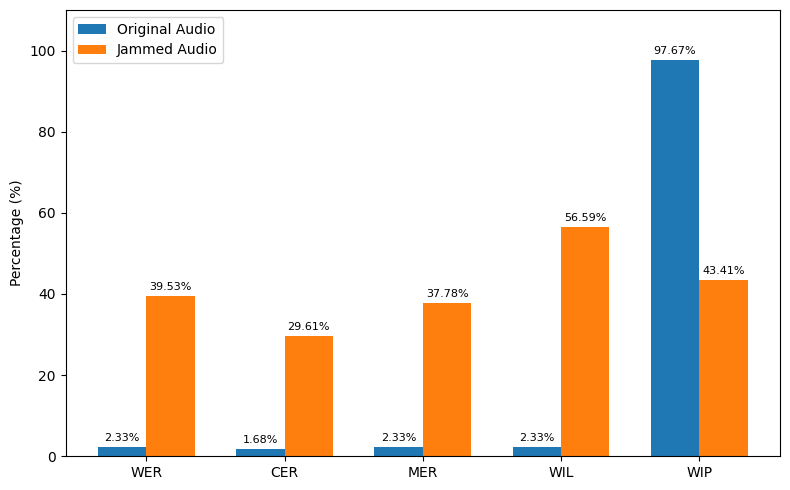

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ==== Input metrics (percent) ====
metrics = {
    "WER": {"Original Audio": 2.33, "Jammed Audio": 39.53},
    "CER": {"Original Audio": 1.68, "Jammed Audio": 29.61},  # <-- CER 추가
    "MER": {"Original Audio": 2.33, "Jammed Audio": 37.78},
    "WIL": {"Original Audio": 2.33, "Jammed Audio": 56.59},
    "WIP": {"Original Audio": 97.67, "Jammed Audio": 43.41},
}

# Original을 왼쪽, Jammed를 오른쪽으로
df = pd.DataFrame(metrics).T[["Original Audio", "Jammed Audio"]]
df.index.name = "Metric"

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df.index))
bar_width = 0.35

# Bars: Original(왼쪽), Jammed(오른쪽)
ax.bar([i - bar_width/2 for i in x], df["Original Audio"].values,
       width=bar_width, label="Original Audio")
ax.bar([i + bar_width/2 for i in x], df["Jammed Audio"].values,
       width=bar_width, label="Jammed Audio")

ax.set_xticks(list(x))
ax.set_xticklabels(df.index)
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 110)  # 97% 라벨 안 잘리도록 여유
ax.legend()

# 값 라벨 표시
for i, val in enumerate(df["Original Audio"].values):
    ax.text(i - bar_width/2, val + 1, f"{val:.2f}%",
            ha="center", va="bottom", fontsize=8)
for i, val in enumerate(df["Jammed Audio"].values):
    ax.text(i + bar_width/2, val + 1, f"{val:.2f}%",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
import math
import numpy as np

def _load_audio(path):
    """
    path의 오디오 파일을 로드해서 (mono float32, sr)를 반환.
    우선 soundfile 사용, 실패 시 scipy.io.wavfile 사용.
    """
    try:
        import soundfile as sf
        x, sr = sf.read(path, always_2d=False)
    except Exception:
        from scipy.io import wavfile
        sr, x = wavfile.read(path)
    # mono & float32 정규화
    if x.ndim > 1:
        x = np.mean(x, axis=1)
    if np.issubdtype(x.dtype, np.integer):
        info = np.iinfo(x.dtype)
        x = x.astype(np.float32) / max(abs(info.min), info.max)
    else:
        x = x.astype(np.float32)
    return x, sr

def _slice_seconds(x, sr, sec_range):
    """sec_range=(start,end) [초] 구간만 잘라서 반환. None이면 전체."""
    if sec_range is None:
        return x
    s0, s1 = sec_range
    i0 = max(0, int(round(s0 * sr)))
    i1 = min(len(x), int(round(s1 * sr)))
    if i0 >= i1:
        raise ValueError(f"잘못된 구간: {sec_range}")
    return x[i0:i1]

def _apply_band(x, sr, band_hz=None, order=4, zero_phase=True):
    """
    band_hz: None | (low, high) | (low, None) | (None, high)
      - (300, 3400) 같이 주면 band-pass
      - (300, None)  이면 high-pass
      - (None, 3400) 이면 low-pass
    """
    if band_hz is None:
        return x
    try:
        from scipy.signal import butter, filtfilt, lfilter
    except Exception:
        # scipy 없으면 필터 생략
        return x

    nyq = 0.5 * sr
    lo, hi = band_hz
    if lo is None and hi is None:
        return x

    if lo is not None and hi is not None:
        btype = "bandpass"; Wn = [max(1e-6, lo/nyq), min(0.999999, hi/nyq)]
    elif lo is not None:
        btype = "highpass"; Wn = max(1e-6, lo/nyq)
    else:
        btype = "lowpass";  Wn = min(0.999999, hi/nyq)

    b, a = butter(order, Wn, btype=btype)
    if zero_phase:
        return filtfilt(b, a, x).astype(np.float32)
    else:
        return lfilter(b, a, x).astype(np.float32)

def compute_rms(x, remove_dc=True, eps=1e-12):
    """RMS = sqrt(mean((x - mean(x))^2)) (remove_dc=True일 때)"""
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return 0.0
    if remove_dc:
        x = x - np.mean(x)
    return float(np.sqrt(np.mean(x * x) + eps))

def sjr_db(rms_speech, rms_jamming, floor_db=-300.0):
    """SJR(dB) = 20*log10(RMS_speech / RMS_jamming)"""
    if rms_jamming <= 0:
        return float("inf")
    val = 20.0 * math.log10(rms_speech / rms_jamming)
    return max(val, floor_db)

def compute_sjr_from_paths(
    speech_path,
    jamming_path,
    speech_range=None,   # 예: (0, 10)  -> 0~10초 구간
    jamming_range=None,  # 예: (20, 30) -> 20~30초 구간
    remove_dc=True,
    band_hz=None         # 예: (300, 3400) or None
):
    """
    두 개의 '파일 경로'를 받아 논문 방식대로 SJR을 계산.
    반환: dict(rms_speech, rms_jamming, SJR_dB, sr_speech, sr_jamming)
    """
    x_s, sr_s = _load_audio(speech_path)
    x_j, sr_j = _load_audio(jamming_path)

    if sr_s != sr_j:
        print(f"[경고] 샘플레이트 불일치: speech={sr_s} Hz, jamming={sr_j} Hz")

    x_s = _slice_seconds(x_s, sr_s, speech_range)
    x_j = _slice_seconds(x_j, sr_j, jamming_range)

    x_s = _apply_band(x_s, sr_s, band_hz)
    x_j = _apply_band(x_j, sr_j, band_hz)

    rms_s = compute_rms(x_s, remove_dc=remove_dc)
    rms_j = compute_rms(x_j, remove_dc=remove_dc)
    sjr   = sjr_db(rms_s, rms_j)

    return {
        "rms_speech":  rms_s,
        "rms_jamming": rms_j,
        "SJR_dB":      sjr,
        "sr_speech":   sr_s,
        "sr_jamming":  sr_j,
        "len_speech":  len(x_s)/sr_s if sr_s>0 else 0.0,
        "len_jamming": len(x_j)/sr_j if sr_j>0 else 0.0,
    }

def compute_sjr_from_single_file(
    mix_path,
    speech_range,        # 필수: 말소리만 있는 구간
    jamming_range,       # 필수: 재밍만 있는 구간
    remove_dc=True,
    band_hz=None
):
    """
    한 파일에서 구간만 다르게 지정해 SJR 계산(말-only 구간, 재밍-only 구간).
    """
    x, sr = _load_audio(mix_path)
    xs = _slice_seconds(x, sr, speech_range)
    xj = _slice_seconds(x, sr, jamming_range)

    xs = _apply_band(xs, sr, band_hz)
    xj = _apply_band(xj, sr, band_hz)

    rms_s = compute_rms(xs, remove_dc=remove_dc)
    rms_j = compute_rms(xj, remove_dc=remove_dc)
    sjr   = sjr_db(rms_s, rms_j)

    return {
        "rms_speech":  rms_s,
        "rms_jamming": rms_j,
        "SJR_dB":      sjr,
        "sr":          sr,
        "len_speech":  len(xs)/sr if sr>0 else 0.0,
        "len_jamming": len(xj)/sr if sr>0 else 0.0,
    }


In [ ]:
from pprint import pprint
import pandas as pd

# ===== 사용 예시 A: 파일이 각각 있을 때 =====
speech_path  = "/home/Weight/jaewoo_test/00micloaker/12.wav"   # 말소리만 녹음된 파일 경로
jamming_path = "/home/Weight/jaewoo_test/00micloaker/25.signal.wav"      # 재밍만 녹음된 파일 경로

speech_range  = None              # 전체 사용 (예: (0, 10))
jamming_range = None              # 전체 사용 (예: (20, 30))

remove_dc = True                  # DC 제거(논문 정의 충실)
band_hz   = None                  # 예: (300, 3400) 전화대역만 분석하려면 지정


# 예시 A 실행
res_A = compute_sjr_from_paths(
    speech_path, jamming_path,
    speech_range=speech_range,
    jamming_range=jamming_range,
    remove_dc=remove_dc,
    band_hz=band_hz
)


print("=== 결과 A: 파일 분리 ===")
pprint(res_A)

# 표로도 보기 (사용자 선호 반영)
df = pd.DataFrame([
    {"Case":"Separate files", **{k:v for k,v in res_A.items()}},
])
display(df)


=== 결과 A: 파일 분리 ===
{'SJR_dB': -4.70524954700457,
 'len_jamming': 16.366,
 'len_speech': 15.6145,
 'rms_jamming': 0.2651691164763816,
 'rms_speech': 0.15426253513401217,
 'sr_jamming': 8000,
 'sr_speech': 8000}


,Case,rms_speech,rms_jamming,SJR_dB,sr_speech,sr_jamming,len_speech,len_jamming
0,Separate files,0.154263,0.265169,-4.70525,8000,8000,15.6145,16.366


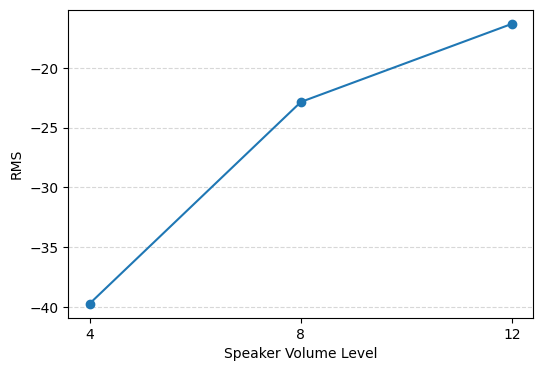

In [ ]:
import matplotlib.pyplot as plt

# ===== 여기를 너 값으로 바꿔줘 (SJR in dB) =====
vol4  = -39.738   # Volume 4에서의 SJR(dB)
vol8  = -22.85     # Volume 8에서의 SJR(dB)
vol12 = -16.303   # Volume 12에서의 SJR(dB)
# ==============================================

x_vals = [4, 8, 12]
y_vals = [vol4, vol8, vol12]

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals, marker='o')  # 색 지정 X (기본)
plt.xticks(x_vals, ['4', '8', '12'])
plt.xlabel('Speaker Volume Level')
plt.ylabel('RMS')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# (옵션) 저장하고 싶으면 주석 해제
# plt.savefig('sjr_vs_volume.png', dpi=200, bbox_inches='tight')

plt.show()


In [1]:
print("hello")

hello
